In [24]:
# %% [imports]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.utils import shuffle

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [112]:
# %% [parameters -- change here only]
START_YEAR     = 1950
TREND_END      = 2015   # <-- change this
SPLIT_YEAR     = 2010   # <-- change this
WATCHLIST_YEAR = TREND_END        # auto: last year of data
HOLDOUT_YEAR   = TREND_END + 1   # auto: 2021
MIN_YEAR_WORDS = 50

In [113]:

# %% [load]
# %% [filter -- always rerun after changing parameters]
df = pd.read_parquet("data/word_year_subject.parquet")
df = df[
    (df["year"] >= START_YEAR) &
    (df["year"] <= TREND_END) &      # uses TREND_END, not hardcoded
    (df["total_title_words"] >= MIN_YEAR_WORDS)
].copy()
print(f"Rows after filter: {len(df):,}")
print(f"Years in data: {df['year'].min()} - {df['year'].max()}")  # confirm cutoff
meta = pd.read_parquet("data/subject_meta.parquet")


Rows after filter: 489,001
Years in data: 1950 - 2015


In [114]:
# %% [filter]
df = df[
    (df["year"] >= START_YEAR) &
    (df["year"] <= TREND_END) &
    (df["total_title_words"] >= MIN_YEAR_WORDS)
].copy()
print(f"Rows after filter: {len(df):,}")


Rows after filter: 489,001


In [115]:

# %% [rising words + lag features]
rising       = pd.read_parquet("data/rising_words_all_subjects.parquet")
rising_pairs = rising[["word", "subject"]].drop_duplicates()
df_rising    = df.merge(rising_pairs, on=["word", "subject"], how="inner")
print(f"Rising word rows: {len(df_rising):,}")

df_rising = df_rising.sort_values(["subject", "word", "year"])
grp       = df_rising.groupby(["subject", "word"])["share"]

df_rising["share_lag1"] = grp.shift(1)
df_rising["share_lag2"] = grp.shift(2)
df_rising["share_lag3"] = grp.shift(3)

def rolling_slope(s, window):
    def _slope(x):
        if np.any(np.isnan(x)) or len(x) < window:
            return np.nan
        return np.polyfit(range(len(x)), x, 1)[0]
    return s.rolling(window).apply(_slope, raw=True)

df_rising["slope_3yr"] = grp.transform(lambda s: rolling_slope(s, 3))
df_rising["slope_5yr"] = grp.transform(lambda s: rolling_slope(s, 5))
df_rising["target"]    = grp.shift(-1)

features = ["share_lag1", "share_lag2", "share_lag3", "slope_3yr", "slope_5yr", "specificity"]
df_model = df_rising.dropna(subset=features + ["target"]).copy()

print(f"Model-ready rows: {len(df_model):,}")
print(f"Share max:        {df_model['share'].max():.4f}")
print(f"Specificity max:  {df_model['specificity'].max():.2f}")

# %% [sanity checks on data]
print(df_model.loc[df_model["share"] == df_model["share"].max(),
      ["word", "subject", "year", "count", "total_title_words"]])
print(df_model.loc[df_model["specificity"] == df_model["specificity"].max(),
      ["word", "subject", "specificity"]])

Rising word rows: 8,614
Model-ready rows: 6,164
Share max:        0.1631
Specificity max:  44.37
       word subject  year  count  total_title_words
4080  space      54  1992     23                141
               word subject  specificity
7253  stratospheric      86    44.374615


In [116]:

# %% [train/test split]
train = df_model[df_model["year"] <  SPLIT_YEAR]
test  = df_model[df_model["year"] >= SPLIT_YEAR]

print(f"Train: {len(train):,} rows | years {train['year'].min()}-{train['year'].max()}")
print(f"Test:  {len(test):,}  rows | years {test['year'].min()}-{test['year'].max()}")

X_train = train[features].values
y_train = train["target"].values
X_test  = test[features].values
y_test  = test["target"].values

Train: 5,134 rows | years 1954-2009
Test:  1,030  rows | years 2010-2014


In [117]:

# %% [baseline: naive lag-1]
y_baseline = test["share_lag1"].values
mae_base   = mean_absolute_error(y_test, y_baseline)
rmse_base  = np.sqrt(mean_squared_error(y_test, y_baseline))
print(f"Baseline (lag-1)  MAE={mae_base:.6f}  RMSE={rmse_base:.6f}")


Baseline (lag-1)  MAE=0.004184  RMSE=0.007571


In [118]:

# %% [ridge regression]
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred = ridge.predict(X_test_s)

mae_ridge  = mean_absolute_error(y_test, y_pred)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Ridge             MAE={mae_ridge:.6f}  RMSE={rmse_ridge:.6f}")

coef_df = pd.DataFrame({
    "feature": features,
    "coef":    ridge.coef_
}).sort_values("coef", key=abs, ascending=False)
print(coef_df.to_string(index=False))

Ridge             MAE=0.003309  RMSE=0.005844
    feature      coef
 share_lag2  0.009451
  slope_3yr  0.004488
 share_lag1  0.004174
  slope_5yr -0.001917
 share_lag3  0.001659
specificity -0.000603


In [119]:

# %% [leakage check]
y_shuffled = shuffle(y_train, random_state=42)
ridge_sh   = Ridge(alpha=1.0)
ridge_sh.fit(X_train_s, y_shuffled)
y_pred_sh  = ridge_sh.predict(X_test_s)
rmse_sh    = np.sqrt(mean_squared_error(y_test, y_pred_sh))
print(f"Shuffled target   RMSE={rmse_sh:.6f}  (should be >> Ridge RMSE if no leakage)")


Shuffled target   RMSE=0.012993  (should be >> Ridge RMSE if no leakage)


In [120]:

# %% [gradient boosting]
gbr = GradientBoostingRegressor(
    n_estimators=200, max_depth=3,
    learning_rate=0.05, subsample=0.8, random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
print(f"GBR   MAE={mae_gbr:.6f}  RMSE={rmse_gbr:.6f}")

fi = pd.DataFrame({
    "feature":    features,
    "importance": gbr.feature_importances_
}).sort_values("importance", ascending=False)
print(fi.to_string(index=False))

GBR   MAE=0.003482  RMSE=0.006096
    feature  importance
 share_lag1    0.396278
 share_lag2    0.291146
 share_lag3    0.213309
  slope_3yr    0.053194
  slope_5yr    0.024831
specificity    0.021243


In [121]:

# %% [ranking evaluation]
test_copy = test.copy()
test_copy["y_pred_ridge"]     = y_pred
test_copy["actual_change"]    = test_copy["target"]       - test_copy["share_lag1"]
test_copy["predicted_change"] = test_copy["y_pred_ridge"] - test_copy["share_lag1"]
test_copy["correct_direction"] = (
    np.sign(test_copy["actual_change"]) == np.sign(test_copy["predicted_change"])
)
print(f"Direction accuracy: {test_copy['correct_direction'].mean():.1%}")

ndcg_results = []
for year, grp in test_copy.groupby("year"):
    if len(grp) < 5:
        continue
    ndcg_results.append({
        "year": year,
        "ndcg": ndcg_score([grp["target"].values], [grp["y_pred_ridge"].values])
    })

ndcg_df = pd.DataFrame(ndcg_results)
print(f"Mean NDCG@all: {ndcg_df['ndcg'].mean():.3f}")
print(ndcg_df.set_index("year")["ndcg"].round(3).to_string())


Direction accuracy: 68.7%
Mean NDCG@all: 0.961
year
2010    0.986
2011    0.951
2012    0.973
2013    0.964
2014    0.930


QA1 PASS: train ends 2009, test starts 2010
QA2: 302 pairs in both splits (expected)
QA3 PASS: target is shift(-1), confirmed by dropna
QA4 PASS: all share values in [0, 1]
QA5 PASS: no duplicate rows


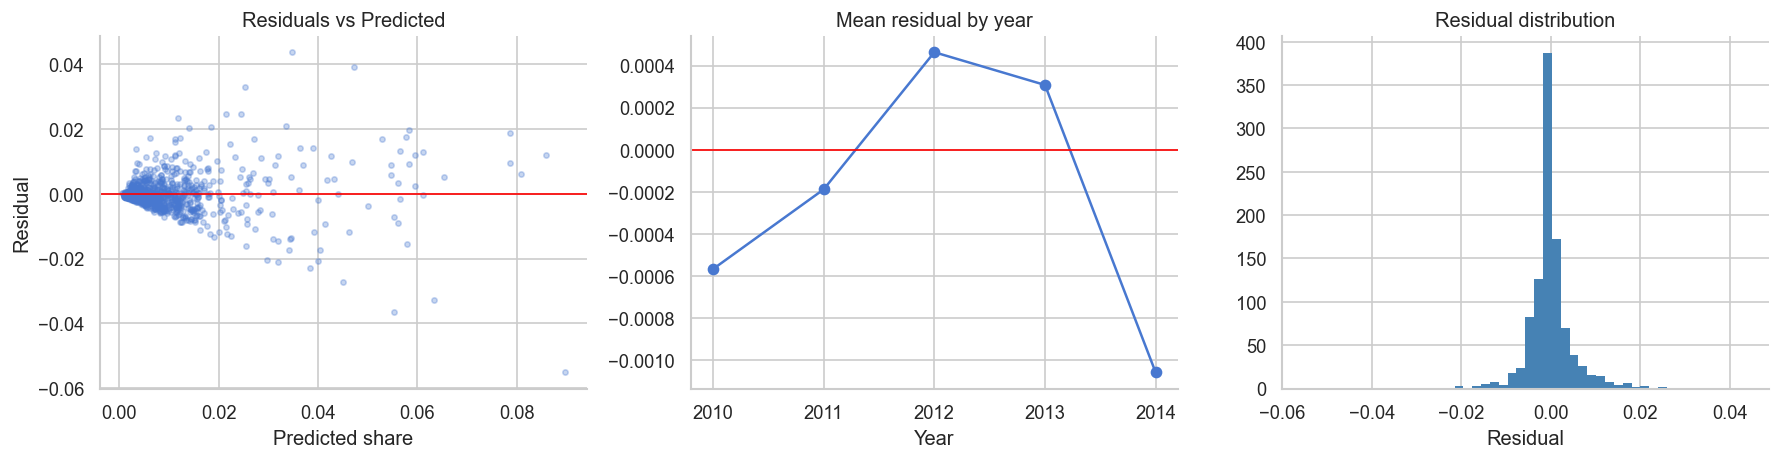

Mean residual: -0.000157
Std residual:  0.005845
                                          subject_name     rmse      mae    n
                            Abstract harmonic analysis 0.020083 0.017140  6.0
           Finite differences and functional equations 0.019672 0.016547  2.0
                                      General topology 0.019008 0.012355 18.0
                         Approximations and expansions 0.015490 0.010032 15.0
                          Convex and discrete geometry 0.012044 0.009084 18.0
         Several complex variables and analytic spaces 0.010295 0.007447 16.0
         Order, lattices, ordered algebraic structures 0.010205 0.009720  2.0
                    Mechanics of particles and systems 0.010119 0.008473  9.0
                        Topological groups, Lie groups 0.008465 0.006649 14.0
                                        Quantum Theory 0.008105 0.005076 15.0
                                              Geometry 0.007351 0.005258 25.0
               

In [122]:

# %% [QA]
assert train["year"].max() < SPLIT_YEAR
assert test["year"].min()  >= SPLIT_YEAR
print(f"QA1 PASS: train ends {train['year'].max()}, test starts {test['year'].min()}")

train_pairs = set(zip(train["word"], train["subject"]))
test_pairs  = set(zip(test["word"],  test["subject"]))
print(f"QA2: {len(train_pairs & test_pairs)} pairs in both splits (expected)")

assert (df_model["year"] < df_model["year"].max()).any()
print("QA3 PASS: target is shift(-1), confirmed by dropna")

assert df_model["share"].between(0, 1).all()
assert df_model["target"].between(0, 1).all()
assert df_model["share_lag1"].between(0, 1).all()
print("QA4 PASS: all share values in [0, 1]")

assert df_model.duplicated(subset=["word", "subject", "year"]).sum() == 0
print("QA5 PASS: no duplicate rows")

# %% [QA6: residual plots]
test_copy["residual"] = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(y_pred, test_copy["residual"], alpha=0.3, s=10)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Predicted share")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

test_copy.groupby("year")["residual"].mean().plot(ax=axes[1], marker="o")
axes[1].axhline(0, color="red", linewidth=1)
axes[1].set_title("Mean residual by year")
axes[1].set_xlabel("Year")

axes[2].hist(test_copy["residual"], bins=50, color="steelblue", edgecolor="none")
axes[2].set_title("Residual distribution")
axes[2].set_xlabel("Residual")

sns.despine()
plt.tight_layout()
plt.show()
print(f"Mean residual: {test_copy['residual'].mean():.6f}")
print(f"Std residual:  {test_copy['residual'].std():.6f}")

# %% [QA7: per-subject RMSE]
per_subject = (
    test_copy.groupby("subject")
    .apply(lambda g: pd.Series({
        "rmse": np.sqrt(mean_squared_error(g["target"], g["y_pred_ridge"])),
        "mae":  mean_absolute_error(g["target"], g["y_pred_ridge"]),
        "n":    len(g)
    }), include_groups=False)
    .reset_index()
    .merge(meta, on="subject")
    .sort_values("rmse", ascending=False)
)
print(per_subject[["subject_name", "rmse", "mae", "n"]].to_string(index=False))


In [123]:

# %% [multi-window experiment]
def run_experiment(split_year, trend_end):
    df_exp = pd.read_parquet("data/word_year_subject.parquet")
    df_exp = df_exp[
        (df_exp["year"] >= START_YEAR) &
        (df_exp["year"] <= trend_end) &
        (df_exp["total_title_words"] >= MIN_YEAR_WORDS)
    ].copy()

    df_r = df_exp.merge(rising_pairs, on=["word", "subject"], how="inner")
    df_r = df_r.sort_values(["subject", "word", "year"])
    g    = df_r.groupby(["subject", "word"])["share"]

    df_r["share_lag1"] = g.shift(1)
    df_r["share_lag2"] = g.shift(2)
    df_r["share_lag3"] = g.shift(3)
    df_r["slope_3yr"]  = g.transform(lambda s: rolling_slope(s, 3))
    df_r["slope_5yr"]  = g.transform(lambda s: rolling_slope(s, 5))
    df_r["target"]     = g.shift(-1)
    df_m = df_r.dropna(subset=features + ["target"]).copy()

    tr = df_m[df_m["year"] <  split_year]
    te = df_m[df_m["year"] >= split_year]

    sc   = StandardScaler()
    X_tr = sc.fit_transform(tr[features].values)
    X_te = sc.transform(te[features].values)

    r = Ridge(alpha=1.0)
    r.fit(X_tr, tr["target"].values)
    yp = r.predict(X_te)

    rmse = np.sqrt(mean_squared_error(te["target"].values, yp))
    mae  = mean_absolute_error(te["target"].values, yp)

    te_c = te.copy()
    te_c["y_pred"] = yp
    ndcg_vals = [
        ndcg_score([g["target"].values], [g["y_pred"].values])
        for _, g in te_c.groupby("year") if len(g) >= 5
    ]
    print(f"Split={split_year} | End={trend_end} | "
          f"Train={len(tr):,} | Test={len(te):,} | "
          f"RMSE={rmse:.6f} | MAE={mae:.6f} | NDCG={np.mean(ndcg_vals):.3f}")
    return rmse, mae, np.mean(ndcg_vals)

for split, end in [(2005, 2015), (2008, 2018), (2010, 2020), (2013, 2023)]:
    run_experiment(split, end)


Split=2005 | End=2015 | Train=4,076 | Test=2,088 | RMSE=0.006022 | MAE=0.003527 | NDCG=0.955
Split=2008 | End=2018 | Train=4,694 | Test=2,120 | RMSE=0.005822 | MAE=0.003307 | NDCG=0.956
Split=2010 | End=2020 | Train=5,153 | Test=2,180 | RMSE=0.005779 | MAE=0.003260 | NDCG=0.962
Split=2013 | End=2023 | Train=5,854 | Test=2,393 | RMSE=0.006334 | MAE=0.003538 | NDCG=0.959


In [124]:

# %% [watchlist: refit on full data, predict HOLDOUT_YEAR]
X_full   = df_model[features].values
y_full   = df_model["target"].values

scaler_full = StandardScaler()
X_full_s    = scaler_full.fit_transform(X_full)
ridge_full  = Ridge(alpha=1.0)
ridge_full.fit(X_full_s, y_full)

latest = (
    df_rising
    .dropna(subset=features)
    .sort_values("year")
    .groupby(["word", "subject"])
    .last()
    .reset_index()
)

latest_watch = latest[latest["year"] == WATCHLIST_YEAR].copy()
print(f"Words with full features at {WATCHLIST_YEAR}: {len(latest_watch)}")

X_watch = scaler_full.transform(latest_watch[features].values)
latest_watch["predicted_share"] = ridge_full.predict(X_watch)
latest_watch["predicted_change"] = latest_watch["predicted_share"] - latest_watch["share_lag1"]

watchlist = (
    latest_watch
    .merge(meta, on="subject")
    .sort_values("predicted_share", ascending=False)
    [["subject_name", "word", "share", "predicted_share", "predicted_change", "slope_3yr", "specificity"]]
)

top5 = (
    watchlist
    .groupby("subject_name")
    .apply(lambda g: g.nlargest(5, "predicted_share"), include_groups=False)
    .reset_index(level=0)
    .reset_index(drop=True)
)
print(f"Watchlist: {len(top5)} words across {top5['subject_name'].nunique()} subjects")

top5.to_parquet(f"data/watchlist_{HOLDOUT_YEAR}.parquet", index=False)
top5.to_csv(f"data/watchlist_{HOLDOUT_YEAR}.csv", index=False)
print(f"Saved watchlist_{HOLDOUT_YEAR}")


Words with full features at 2015: 214
Watchlist: 189 words across 51 subjects
Saved watchlist_2016


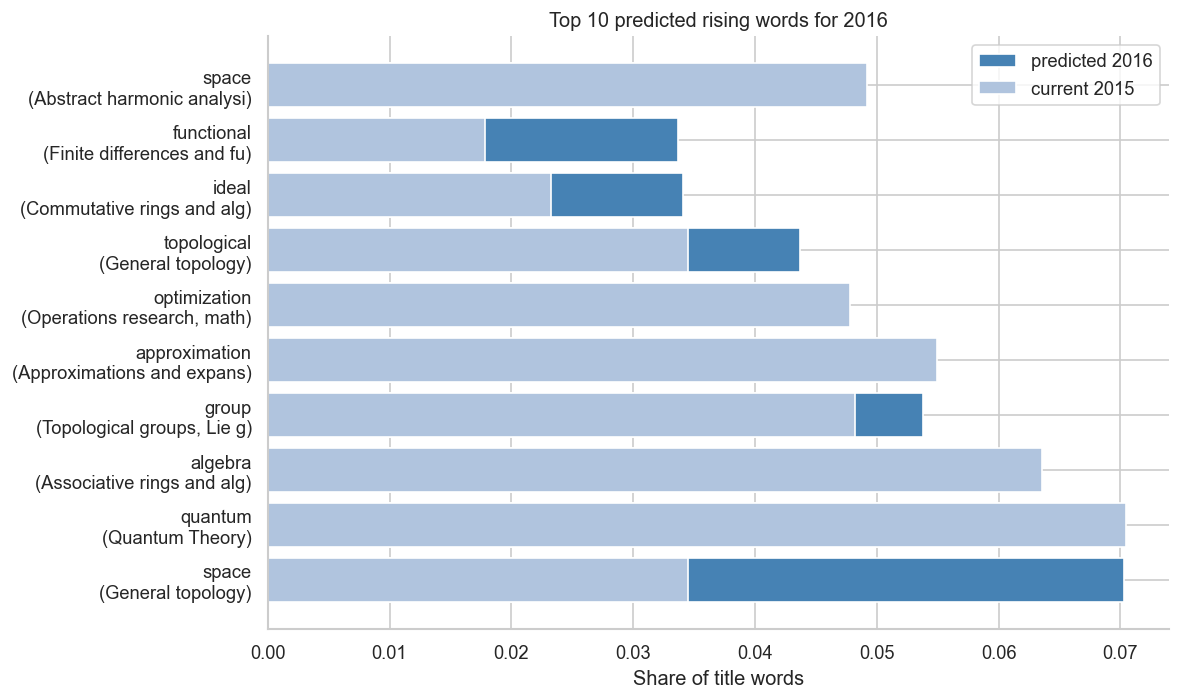

In [125]:

# %% [plot: top 10 globally]
top10_global = watchlist.nlargest(10, "predicted_share")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top10_global["word"] + "\n(" + top10_global["subject_name"].str[:25] + ")",
    top10_global["predicted_share"], color="steelblue", label=f"predicted {HOLDOUT_YEAR}"
)
ax.barh(
    top10_global["word"] + "\n(" + top10_global["subject_name"].str[:25] + ")",
    top10_global["share"], color="lightsteelblue", label=f"current {WATCHLIST_YEAR}"
)
ax.set_xlabel("Share of title words")
ax.set_title(f"Top 10 predicted rising words for {HOLDOUT_YEAR}")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


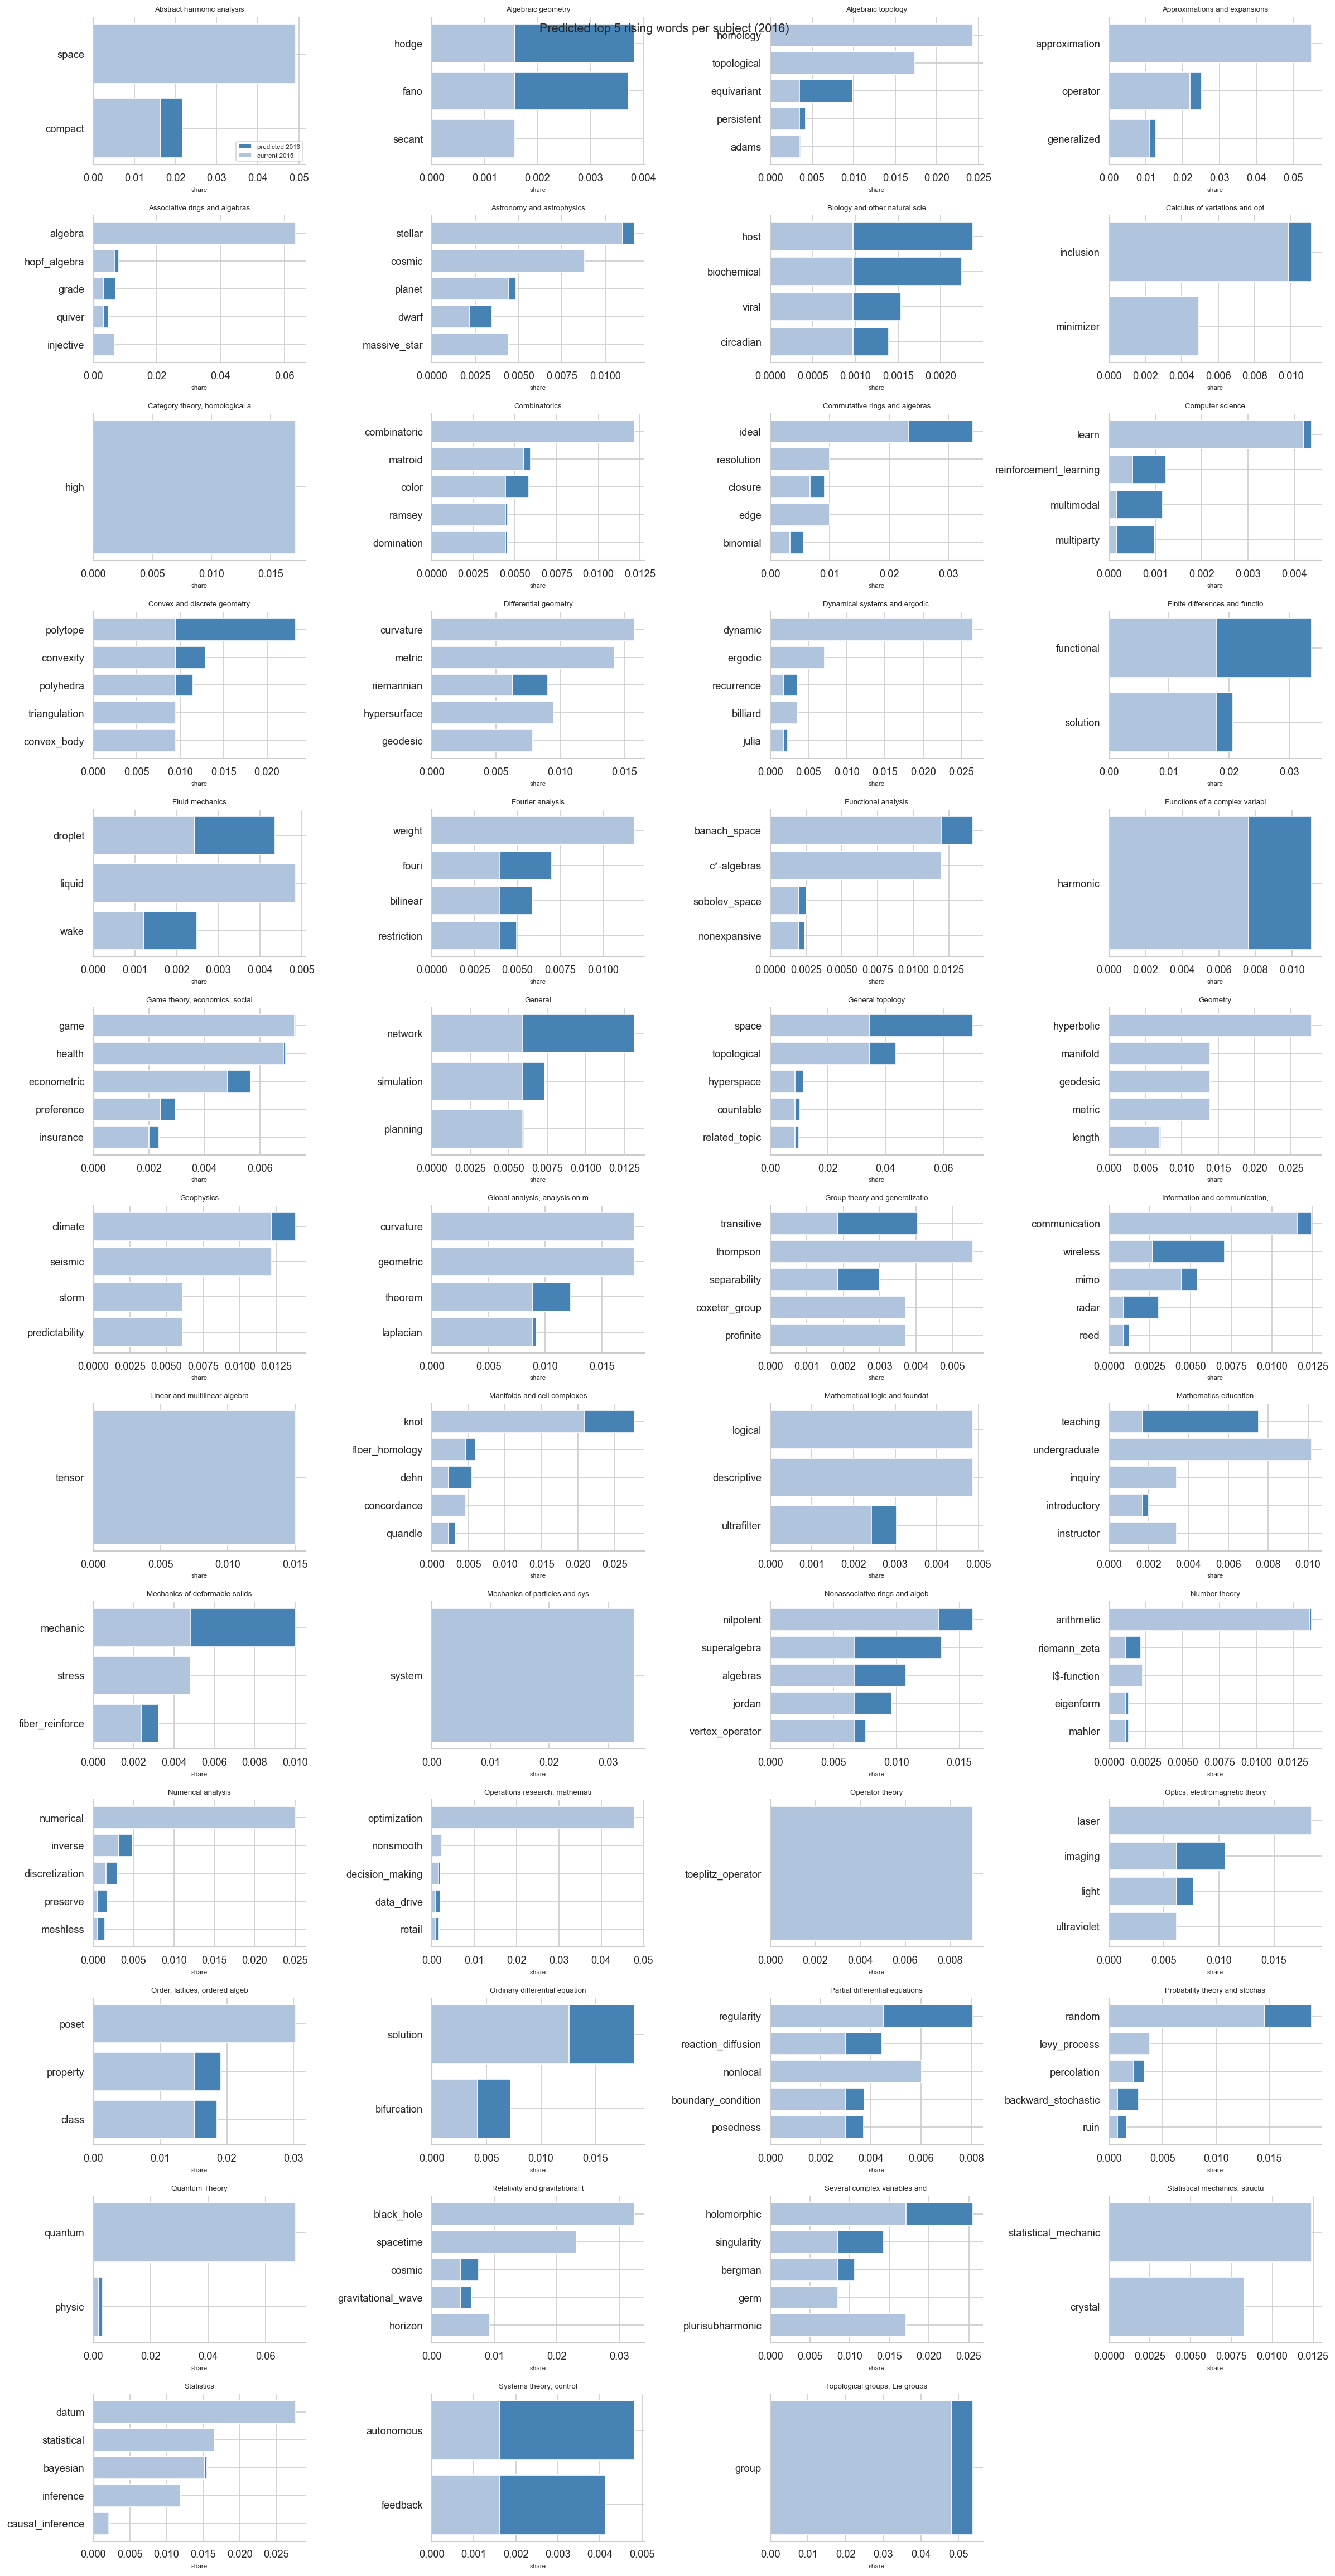

In [126]:

# %% [plot: top 5 per subject small multiples]
subjects = top5["subject_name"].unique()
ncols    = 4
nrows    = -(-len(subjects) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3))
axes = axes.flatten()

for ax, subj in zip(axes, subjects):
    sub = top5[top5["subject_name"] == subj].sort_values("predicted_share")
    ax.barh(sub["word"], sub["predicted_share"],  color="steelblue",      label=f"predicted {HOLDOUT_YEAR}")
    ax.barh(sub["word"], sub["share"],            color="lightsteelblue", label=f"current {WATCHLIST_YEAR}")
    ax.set_title(subj[:30], fontsize=8)
    ax.set_xlabel("share", fontsize=7)
    sns.despine(ax=ax)

axes[0].legend(fontsize=7)
for ax in axes[len(subjects):]:
    ax.set_visible(False)

plt.suptitle(f"Predicted top 5 rising words per subject ({HOLDOUT_YEAR})", fontsize=13)
plt.tight_layout()
plt.show()


In [127]:

# %% [holdout comparison]
actual_holdout = (
    pd.read_parquet("data/word_year_subject.parquet")
    .query(f"year == {HOLDOUT_YEAR} and total_title_words >= {MIN_YEAR_WORDS}")
    [["word", "subject", "share"]]
    .rename(columns={"share": "actual_share"})
    .merge(meta, on="subject")
)

comparison = top5.merge(actual_holdout, on=["word", "subject_name"], how="left")


In [128]:

# derive and exclude sparse subjects
SPARSE = (
    comparison.groupby("subject_name")["actual_share"]
    .sum()
    .pipe(lambda s: s[s == 0].index.tolist())
)
print(f"Subjects excluded (no {HOLDOUT_YEAR} data): {SPARSE}")

comparison = comparison[~comparison["subject_name"].isin(SPARSE)].copy()
missing    = comparison["actual_share"].isna().sum()
print(f"Words evaluated:              {len(comparison)}")
print(f"Words with no {HOLDOUT_YEAR} appearance: {missing} (filled to 0)")
comparison["actual_share"] = comparison["actual_share"].fillna(0)


Subjects excluded (no 2016 data): ['Calculus of variations and optimal control', 'Finite differences and functional equations', 'Order, lattices, ordered algebraic structures', 'Statistical mechanics, structure of matter']
Words evaluated:              180
Words with no 2016 appearance: 60 (filled to 0)


In [129]:

# %% [holdout metrics]
mae  = mean_absolute_error(comparison["actual_share"], comparison["predicted_share"])
rmse = np.sqrt(mean_squared_error(comparison["actual_share"], comparison["predicted_share"]))

comparison["actual_change"]    = comparison["actual_share"]    - comparison["share"]
comparison["predicted_change"] = comparison["predicted_share"] - comparison["share"]
comparison["correct_direction"] = (
    np.sign(comparison["actual_change"]) == np.sign(comparison["predicted_change"])
)
print(f"MAE:                {mae:.6f}")
print(f"RMSE:               {rmse:.6f}")
print(f"Direction accuracy: {comparison['correct_direction'].mean():.1%}")


MAE:                0.004721
RMSE:               0.007384
Direction accuracy: 57.8%


In [130]:

# %% [holdout NDCG per subject]
ndcg_rows = []
for subj, grp in comparison.groupby("subject_name"):
    if len(grp) < 2:
        continue
    ndcg_rows.append({
        "subject_name": subj,
        "ndcg": ndcg_score([grp["actual_share"].values], [grp["predicted_share"].values]),
        "n": len(grp)
    })

ndcg_2024 = pd.DataFrame(ndcg_rows)
print(f"Mean NDCG@5 ({HOLDOUT_YEAR}, {len(ndcg_2024)} subjects): {ndcg_2024['ndcg'].mean():.3f}")
print(ndcg_2024.sort_values("ndcg").to_string(index=False))


Mean NDCG@5 (2016, 41 subjects): 0.922
                                          subject_name     ndcg  n
                      Group theory and generalizations 0.386853  5
                Global analysis, analysis on manifolds 0.619906  4
                                              Geometry 0.630930  5
                                      Fourier analysis 0.630930  4
                                    Algebraic topology 0.736364  5
                               Systems theory; control 0.796708  2
                     Nonassociative rings and algebras 0.796708  5
                   Relativity and gravitational theory 0.800872  5
                    Mathematical logic and foundations 0.859719  3
                            Abstract harmonic analysis 0.859719  2
                            Astronomy and astrophysics 0.862724  5
                                    Algebraic geometry 0.922495  3
                                         Number theory 0.971727  5
                       

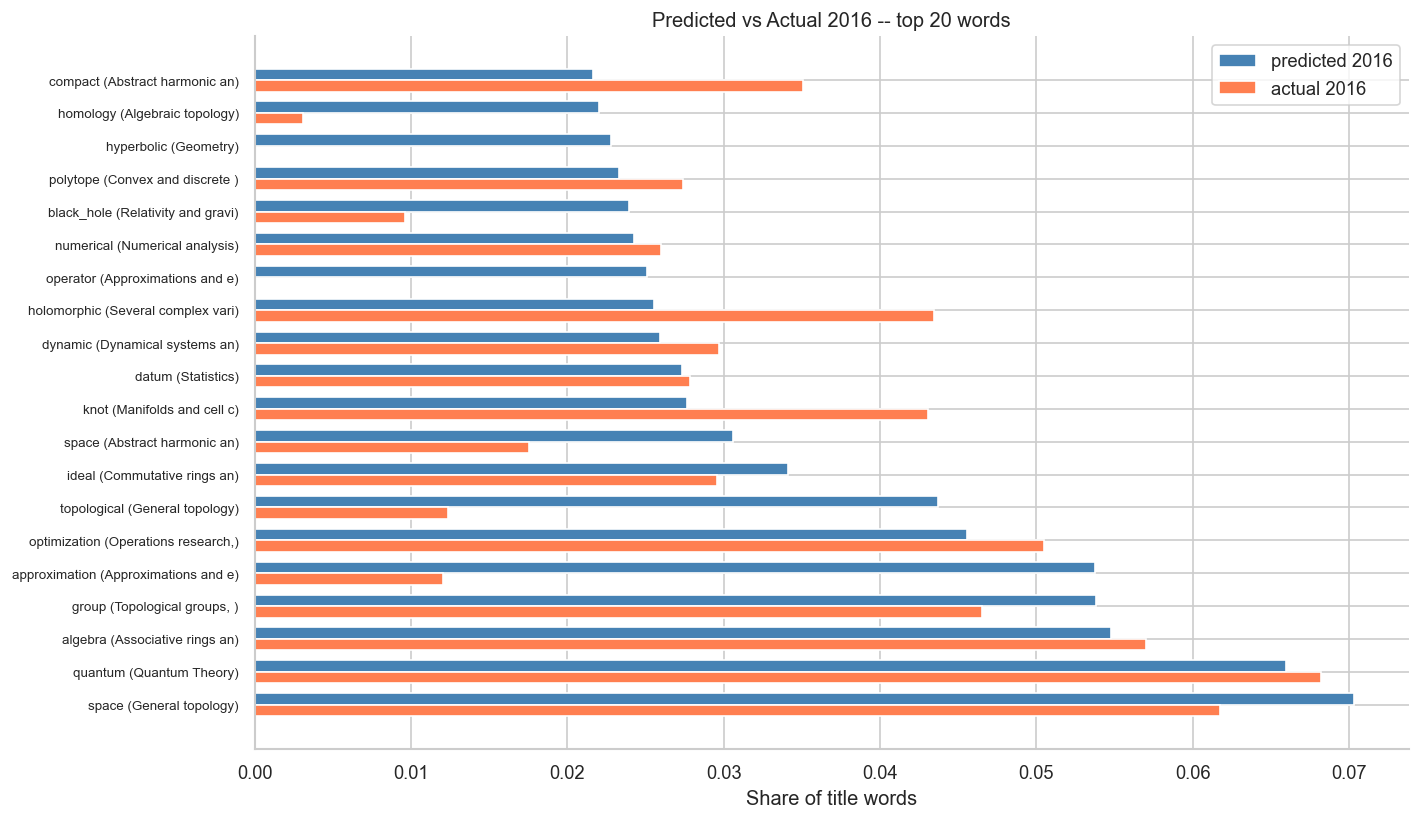

In [131]:

# %% [plot: predicted vs actual top 20]
top20 = comparison.nlargest(20, "predicted_share")

fig, ax = plt.subplots(figsize=(12, 7))
x     = np.arange(len(top20))
width = 0.35
ax.barh(x + width/2, top20["predicted_share"], width, label=f"predicted {HOLDOUT_YEAR}", color="steelblue")
ax.barh(x - width/2, top20["actual_share"],    width, label=f"actual {HOLDOUT_YEAR}",    color="coral")
ax.set_yticks(x)
ax.set_yticklabels(
    top20["word"] + " (" + top20["subject_name"].str[:20] + ")",
    fontsize=8
)
ax.set_xlabel("Share of title words")
ax.set_title(f"Predicted vs Actual {HOLDOUT_YEAR} -- top 20 words")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()



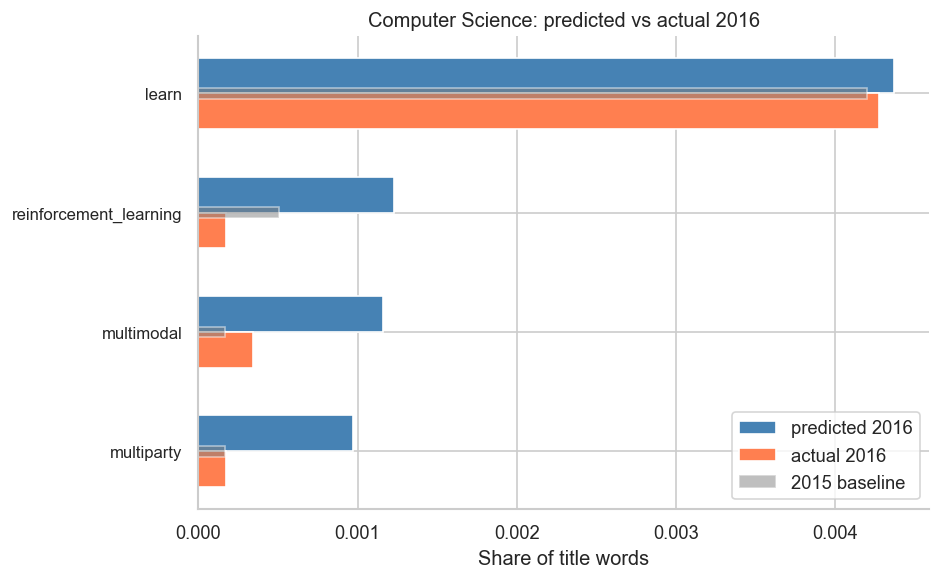

In [132]:

# %% [CS deep dive]
cs = (
    comparison[comparison["subject_name"] == "Computer science"]
    .sort_values("predicted_share", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
x     = np.arange(len(cs))
width = 0.3
ax.barh(x + width/2, cs["predicted_share"], width, label=f"predicted {HOLDOUT_YEAR}", color="steelblue")
ax.barh(x - width/2, cs["actual_share"],    width, label=f"actual {HOLDOUT_YEAR}",    color="coral")
ax.barh(x,           cs["share"], width * 0.3,     label=f"{WATCHLIST_YEAR} baseline", color="gray", alpha=0.5)
ax.set_yticks(x)
ax.set_yticklabels(cs["word"], fontsize=10)
ax.set_xlabel("Share of title words")
ax.set_title(f"Computer Science: predicted vs actual {HOLDOUT_YEAR}")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


In [133]:

# %% [biggest misses and best predictions]
comparison["abs_error"] = (comparison["predicted_share"] - comparison["actual_share"]).abs()

print("\nBiggest misses:")
print(
    comparison.nlargest(10, "abs_error")
    [["subject_name", "word", "share", "predicted_share", "actual_share", "abs_error"]]
    .round(5).to_string(index=False)
)
print("\nBest predictions:")
print(
    comparison.nsmallest(10, "abs_error")
    [["subject_name", "word", "share", "predicted_share", "actual_share", "abs_error"]]
    .round(5).to_string(index=False)
)



Biggest misses:
                                 subject_name          word   share  predicted_share  actual_share  abs_error
                Approximations and expansions approximation 0.05495          0.05373       0.01205    0.04168
                             General topology   topological 0.03448          0.04368       0.01235    0.03134
                Approximations and expansions      operator 0.02198          0.02510       0.00000    0.02510
                                     Geometry    hyperbolic 0.02778          0.02278       0.00000    0.02278
                           Algebraic topology      homology 0.02431          0.02201       0.00311    0.01890
Several complex variables and analytic spaces   holomorphic 0.01709          0.02551       0.04348    0.01797
                 Manifolds and cell complexes          knot 0.02083          0.02766       0.04305    0.01538
       Global analysis, analysis on manifolds     curvature 0.01786          0.01464       0.00000    0